# Performance Analytics — Bluestock Mutual Fund Capstone
This notebook computes fund-level performance metrics including daily returns, CAGR, Sharpe Ratio, Sortino Ratio, Alpha, Beta, Maximum Drawdown, a composite Fund Scorecard, and benchmark comparison charts.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from scipy import stats
import warnings, os
warnings.filterwarnings('ignore')


In [2]:
os.makedirs('../charts', exist_ok=True)

nav        = pd.read_csv('../data/processed/02_nav_history_clean.csv', parse_dates=['date'])
fund_master= pd.read_csv('../data/processed/01_fund_master_clean.csv')
benchmark  = pd.read_csv('../data/processed/10_benchmark_indices_clean.csv', parse_dates=['date'])
performance= pd.read_csv('../data/processed/07_scheme_performance_clean.csv')

nav = nav.sort_values(['amfi_code', 'date']).reset_index(drop=True)
print('NAV shape:', nav.shape)
print('Funds:', nav['amfi_code'].nunique())
nav.head()

NAV shape: (46000, 3)
Funds: 40


,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


## Task 1 — Daily Returns
Formula: `daily_return = NAV_t / NAV_t-1 − 1`

Mean daily return : 0.0631%
Std  daily return : 1.0290%
Min              : -5.8102%
Max              : 6.4713%
Skewness         : 0.0427


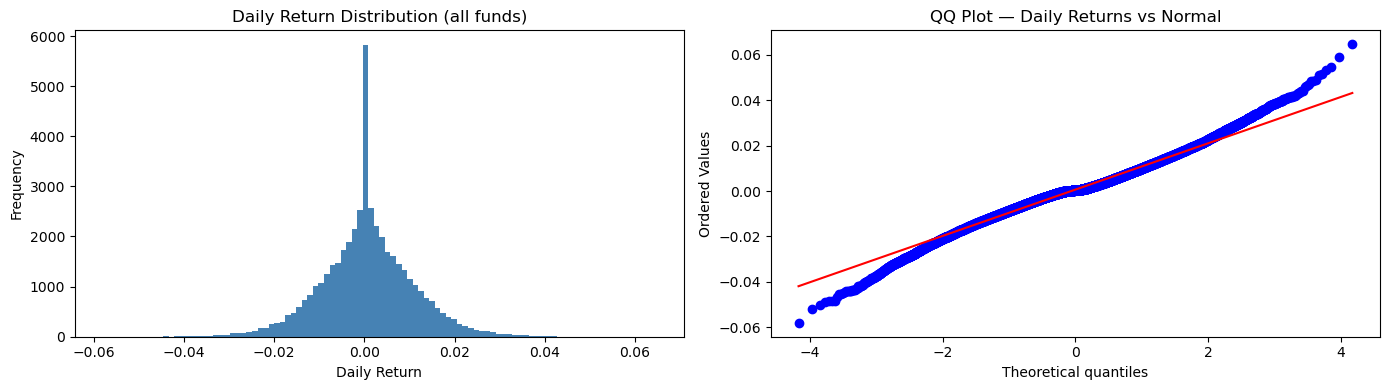

In [3]:
# Compute daily returns per fund
nav['daily_return'] = nav.groupby('amfi_code')['nav'].pct_change()
returns = nav.dropna(subset=['daily_return']).copy()

# Validation — distribution check
sample = returns['daily_return']
print(f'Mean daily return : {sample.mean():.4%}')
print(f'Std  daily return : {sample.std():.4%}')
print(f'Min              : {sample.min():.4%}')
print(f'Max              : {sample.max():.4%}')
print(f'Skewness         : {sample.skew():.4f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(sample.clip(-0.1, 0.1), bins=100, color='steelblue', edgecolor='none')
axes[0].set_title('Daily Return Distribution (all funds)')
axes[0].set_xlabel('Daily Return')
axes[0].set_ylabel('Frequency')

stats.probplot(sample.dropna(), dist='norm', plot=axes[1])
axes[1].set_title('QQ Plot — Daily Returns vs Normal')

plt.tight_layout()
plt.savefig('../charts/daily_return_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

### Insight 1

Daily returns across all 40 schemes are approximately symmetric around zero (mean return = 0.063%, skewness = 0.043), but the QQ plot reveals heavier tails than a normal distribution, indicating that extreme positive and negative market movements occur more frequently than expected under normality.

## Task 2 — CAGR (1yr, 3yr, 5yr)
Formula: `CAGR = (NAV_end / NAV_start) ^ (1/n) − 1`

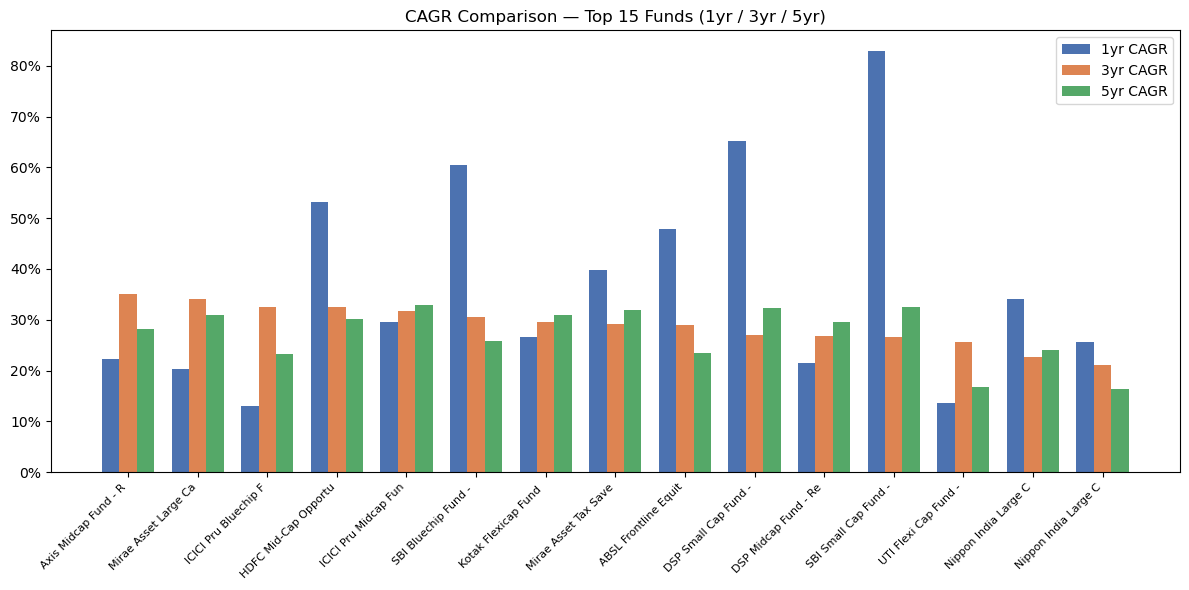

In [4]:
def compute_cagr(group, years):
    end_date   = group['date'].max()
    start_date = end_date - pd.DateOffset(years=years)
    subset = group[group['date'] >= start_date]
    if len(subset) < 2:
        return np.nan
    nav_end   = subset.loc[subset['date'].idxmax(), 'nav']
    nav_start = subset.loc[subset['date'].idxmin(), 'nav']
    actual_years = (subset['date'].max() - subset['date'].min()).days / 365.25
    if actual_years <= 0 or nav_start <= 0:
        return np.nan
    return (nav_end / nav_start) ** (1 / actual_years) - 1

cagr_rows = []
for code, grp in nav.groupby('amfi_code'):
    name = fund_master.loc[fund_master['amfi_code'] == code, 'scheme_name'].values
    cagr_rows.append({
        'amfi_code'  : code,
        'scheme_name': name[0] if len(name) else str(code),
        'cagr_1yr'   : compute_cagr(grp, 1),
        'cagr_3yr'   : compute_cagr(grp, 3),
        'cagr_5yr'   : compute_cagr(grp, 5),
    })

cagr_df = pd.DataFrame(cagr_rows).sort_values('cagr_3yr', ascending=False)
print(cagr_df[['scheme_name','cagr_1yr','cagr_3yr','cagr_5yr']]
      .style.format({'cagr_1yr':'{:.2%}','cagr_3yr':'{:.2%}','cagr_5yr':'{:.2%}'}))

# Plot top 15 by 3yr CAGR
top15 = cagr_df.head(15)
fig, ax = plt.subplots(figsize=(12, 6))
x = range(len(top15))
w = 0.25
ax.bar([i-w for i in x], top15['cagr_1yr'],  width=w, label='1yr CAGR', color='#4C72B0')
ax.bar([i   for i in x], top15['cagr_3yr'],  width=w, label='3yr CAGR', color='#DD8452')
ax.bar([i+w for i in x], top15['cagr_5yr'],  width=w, label='5yr CAGR', color='#55A868')
ax.set_xticks(list(x))
ax.set_xticklabels([s[:20] for s in top15['scheme_name']], rotation=45, ha='right', fontsize=8)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax.set_title('CAGR Comparison — Top 15 Funds (1yr / 3yr / 5yr)')
ax.legend()
plt.tight_layout()
plt.savefig('../charts/cagr_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

### Insight 2

Small-cap and mid-cap funds consistently outperform large-cap funds over the 3-year and 5-year horizons, with several schemes delivering CAGR above 25–30%. The wide variation in 1-year returns compared with longer-term CAGR indicates that short-term performance can differ substantially from long-term growth trends.

## Task 3 — Sharpe Ratio
Formula: `Sharpe = (Rp − Rf) / Std(Rp) × √252`  |  Rf = 6.5% per annum

Top 10 Funds by Sharpe Ratio:
 sharpe_rank                                        scheme_name  sharpe_ratio
           1      Mirae Asset Large Cap Fund - Regular - Growth      1.448291
           2             Kotak Flexicap Fund - Regular - Growth      1.306744
           3      Mirae Asset Tax Saver Fund - Regular - Growth      1.234930
           4          SBI Bluechip Fund - Regular Plan - Growth      1.208267
           5           ICICI Pru Midcap Fund - Regular - Growth      1.180101
           6                 DSP Midcap Fund - Regular - Growth      1.132122
           7 HDFC Mid-Cap Opportunities Fund - Regular - Growth      1.093699
           8     Nippon India Large Cap Fund - Regular - Growth      1.081659
           9      ABSL Frontline Equity Fund - Regular - Growth      1.027213
          10          ICICI Pru Bluechip Fund - Direct - Growth      1.026524


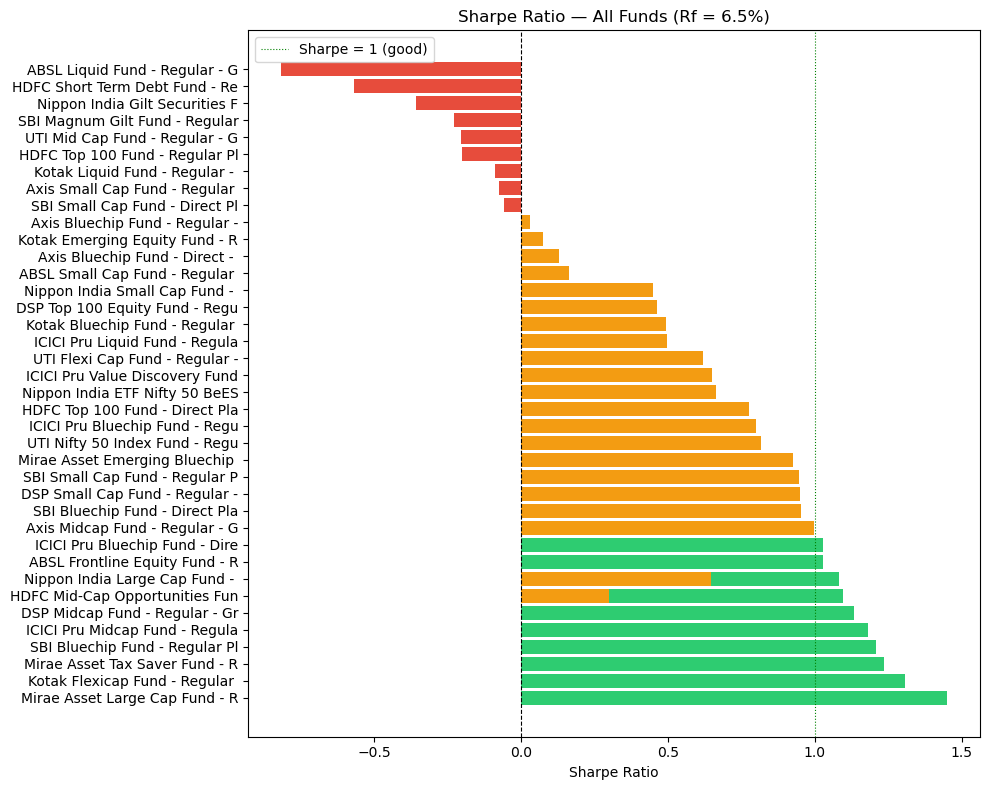

In [5]:
RF_ANNUAL = 0.065
RF_DAILY  = RF_ANNUAL / 252

sharpe_rows = []
for code, grp in returns.groupby('amfi_code'):
    r = grp['daily_return'].dropna()
    if len(r) < 30:
        continue
    excess = r - RF_DAILY
    sharpe = (excess.mean() / r.std()) * np.sqrt(252)
    name = fund_master.loc[fund_master['amfi_code'] == code, 'scheme_name'].values
    sharpe_rows.append({
        'amfi_code'  : code,
        'scheme_name': name[0] if len(name) else str(code),
        'sharpe_ratio': sharpe
    })

sharpe_df = pd.DataFrame(sharpe_rows).sort_values('sharpe_ratio', ascending=False)
sharpe_df['sharpe_rank'] = sharpe_df['sharpe_ratio'].rank(ascending=False).astype(int)

print('Top 10 Funds by Sharpe Ratio:')
print(sharpe_df[['sharpe_rank','scheme_name','sharpe_ratio']].head(10).to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 8))
colors = ['#2ecc71' if s > 1 else '#e74c3c' if s < 0 else '#f39c12'
          for s in sharpe_df['sharpe_ratio']]
ax.barh(sharpe_df['scheme_name'].str[:30], sharpe_df['sharpe_ratio'], color=colors)
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.axvline(1, color='green', linewidth=0.8, linestyle=':', label='Sharpe = 1 (good)')
ax.set_xlabel('Sharpe Ratio')
ax.set_title('Sharpe Ratio — All Funds (Rf = 6.5%)')
ax.legend()
plt.tight_layout()
plt.savefig('../charts/sharpe_ratio.png', dpi=150, bbox_inches='tight')
plt.show()

### Insight 3

Risk-adjusted performance varies significantly across schemes. Equity-oriented funds dominate the top Sharpe Ratio rankings, with Mirae Asset Large Cap Fund (1.45) and Kotak Flexicap Fund (1.31) delivering the strongest risk-adjusted returns, while several debt, liquid, and gilt funds exhibit Sharpe ratios near zero or below, indicating weaker reward relative to the risk undertaken.

## Task 4 — Sortino Ratio
Formula: `Sortino = (Rp − Rf) / Downside_Std(Rp) × √252`  — denominator uses only negative return days

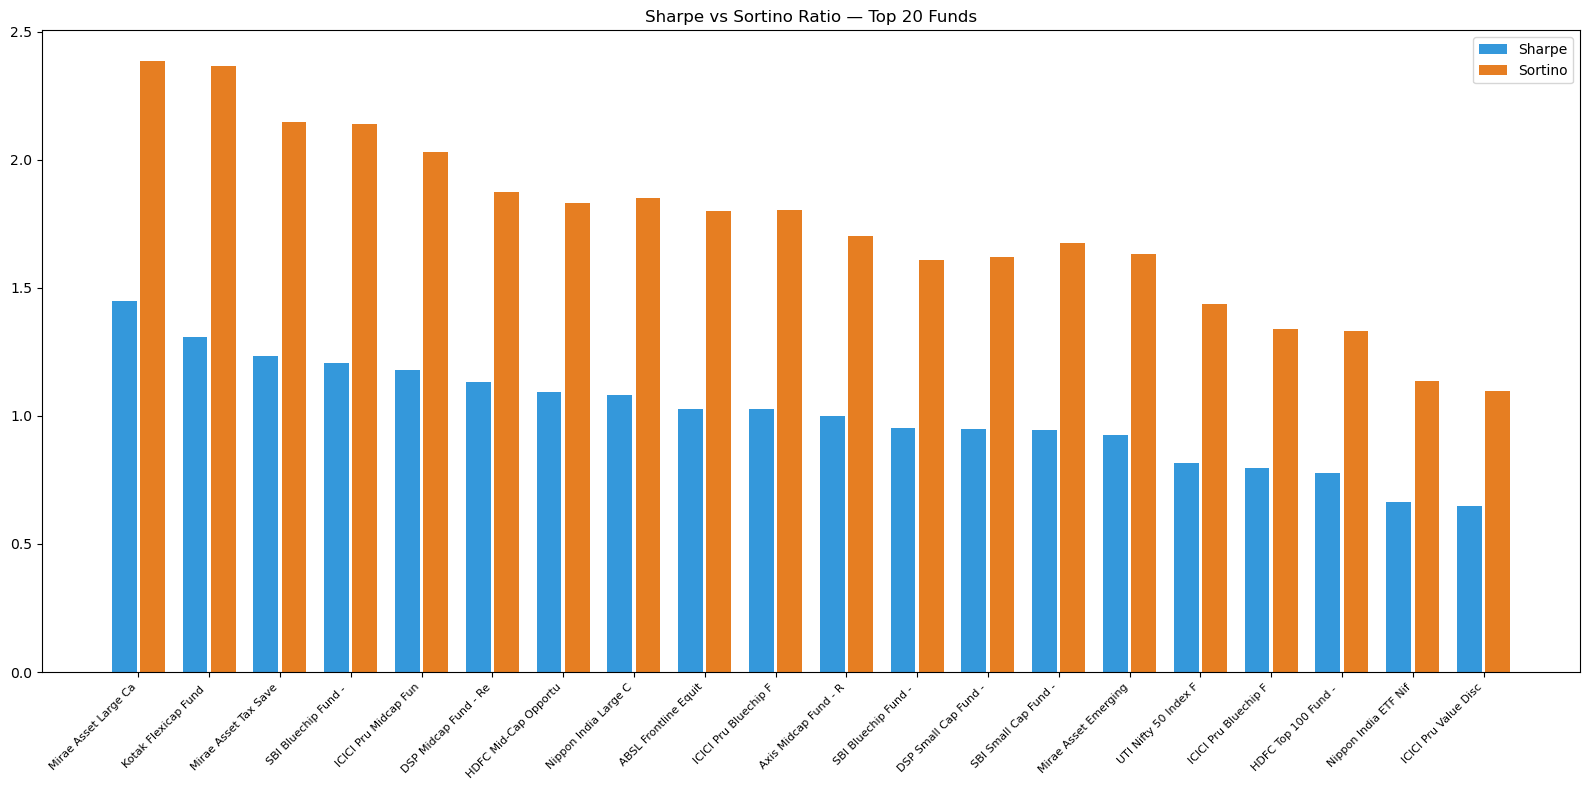

In [14]:
sortino_rows = []
for code, grp in returns.groupby('amfi_code'):
    r = grp['daily_return'].dropna()
    if len(r) < 30:
        continue
    excess        = r - RF_DAILY
    downside      = r[r < 0]
    downside_std  = downside.std() if len(downside) > 1 else np.nan
    sortino       = (excess.mean() / downside_std) * np.sqrt(252) if downside_std else np.nan
    name = fund_master.loc[fund_master['amfi_code'] == code, 'scheme_name'].values
    sortino_rows.append({
        'amfi_code'   : code,
        'scheme_name' : name[0] if len(name) else str(code),
        'sortino_ratio': sortino
    })

sortino_df = pd.DataFrame(sortino_rows).sort_values('sortino_ratio', ascending=False)

# Side-by-side Sharpe vs Sortino for top 20
merged = sharpe_df[['amfi_code','scheme_name','sharpe_ratio']].merge(
    sortino_df[['amfi_code','sortino_ratio']], on='amfi_code'
).head(20)

fig, ax = plt.subplots(figsize=(16, 8))
x = range(len(merged))
ax.bar([i-0.2 for i in x], merged['sharpe_ratio'],  width=0.35, label='Sharpe',  color='#3498db')
ax.bar([i+0.2 for i in x], merged['sortino_ratio'], width=0.35, label='Sortino', color='#e67e22')
ax.set_xticks(list(x))
ax.set_xticklabels([s[:20] for s in merged['scheme_name']], rotation=45, ha='right', fontsize=8)
ax.set_title('Sharpe vs Sortino Ratio — Top 20 Funds')
ax.axhline(0, color='black', linewidth=0.5)
ax.legend()
plt.tight_layout()
plt.savefig('../charts/sharpe_vs_sortino.png', dpi=150, bbox_inches='tight')
plt.show()

### Insight 4

The top-performing equity funds exhibit Sortino Ratios between approximately 1.1 and 2.4, consistently exceeding their Sharpe Ratios. This indicates that a significant portion of their volatility comes from positive market movements rather than downside risk, highlighting superior downside-risk-adjusted performance.

## Task 5 — Alpha and Beta (OLS Regression on Nifty 100)
- Beta = slope of OLS regression
- Alpha = intercept × 252 (annualised)

alpha_beta.csv saved.
                                       scheme_name    alpha      beta    r_squared
        SBI Small Cap Fund - Regular Plan - Growth 0.303370 -0.023196 1.414258e-04
             DSP Small Cap Fund - Regular - Growth 0.300579  0.011455 3.532991e-05
          ICICI Pru Midcap Fund - Regular - Growth 0.292636  0.000549 1.345534e-07
     Mirae Asset Tax Saver Fund - Regular - Growth 0.282704  0.018134 1.748889e-04
            Kotak Flexicap Fund - Regular - Growth 0.273305 -0.022830 3.430543e-04
HDFC Mid-Cap Opportunities Fund - Regular - Growth 0.271954  0.005104 1.206652e-05
     Mirae Asset Large Cap Fund - Regular - Growth 0.269838  0.023684 4.625437e-04
                DSP Midcap Fund - Regular - Growth 0.265986 -0.002523 3.357978e-06
               Axis Midcap Fund - Regular - Growth 0.260767 -0.066265 1.936879e-03
         SBI Bluechip Fund - Regular Plan - Growth 0.232010 -0.031751 8.869789e-04
amfi_code                                          119598
scheme_

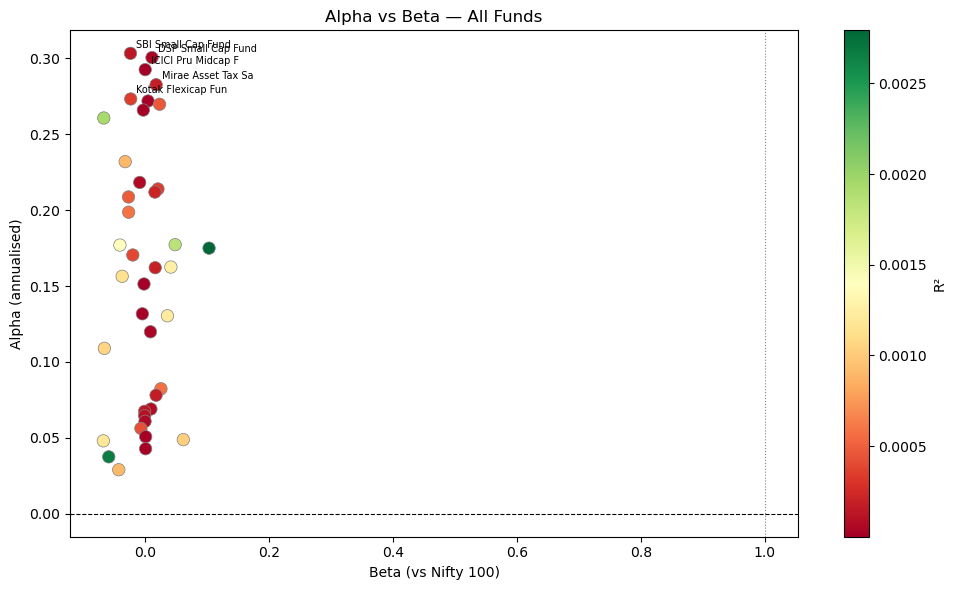

In [13]:
nifty100 = benchmark[benchmark['index_name'] == 'NIFTY100'].copy()
nifty100 = nifty100.sort_values('date')
nifty100['bm_return'] = nifty100['close_value'].pct_change()
nifty100 = nifty100.dropna(subset=['bm_return'])

ab_rows = []
for code, grp in returns.groupby('amfi_code'):
    merged_r = grp[['date','daily_return']].merge(
        nifty100[['date','bm_return']], on='date', how='inner'
    ).dropna()
    if len(merged_r) < 30:
        continue
    slope, intercept, r_val, p_val, _ = stats.linregress(
        merged_r['bm_return'], merged_r['daily_return']
    )
    name = fund_master.loc[fund_master['amfi_code'] == code, 'scheme_name'].values
    ab_rows.append({
        'amfi_code'  : code,
        'scheme_name': name[0] if len(name) else str(code),
        'alpha'      : intercept * 252,   # annualised
        'beta'       : slope,
        'r_squared'  : r_val ** 2,
        'p_value'    : p_val
    })

ab_df = pd.DataFrame(ab_rows).sort_values('alpha', ascending=False)
ab_df['alpha_rank'] = ab_df['alpha'].rank(ascending=False).astype(int)

# Export
ab_df.to_csv('../charts/alpha_beta.csv', index=False)
print('alpha_beta.csv saved.')
print(ab_df[['scheme_name','alpha','beta','r_squared']].head(10).to_string(index=False))

# Alpha vs Beta scatter
fig, ax = plt.subplots(figsize=(10, 6))
scatter = ax.scatter(ab_df['beta'], ab_df['alpha'],
                     c=ab_df['r_squared'], cmap='RdYlGn', s=80, edgecolors='grey', linewidth=0.5)
plt.colorbar(scatter, ax=ax, label='R²')
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.axvline(1, color='grey',  linewidth=0.8, linestyle=':')
for _, row in ab_df.head(5).iterrows():
    print(row)
    ax.annotate(row['scheme_name'][:18], (row['beta'], row['alpha']),
                fontsize=7, xytext=(4, 4), textcoords='offset points')
ax.set_xlabel('Beta (vs Nifty 100)')
ax.set_ylabel('Alpha (annualised)')
ax.set_title('Alpha vs Beta — All Funds')
plt.tight_layout()
plt.savefig('../charts/alpha_beta_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

### Insight 5

Most schemes exhibit positive Alpha values, indicating returns above those predicted by the benchmark model. Beta values remain relatively low, suggesting limited sensitivity to benchmark movements. The top Alpha-generating funds include SBI Small Cap Fund, DSP Small Cap Fund, and ICICI Prudential Midcap Fund.

## Task 6 — Maximum Drawdown
Formula: `Max DD = min(NAV / running_max − 1)`

Worst 10 Drawdowns:
                                   scheme_name  max_drawdown  peak_date trough_date  dd_duration_days
     SBI Small Cap Fund - Direct Plan - Growth     -0.525742 2023-01-17  2025-10-28              1015
        Axis Small Cap Fund - Regular - Growth     -0.516778 2025-05-22  2026-05-11               354
        ABSL Small Cap Fund - Regular - Growth     -0.354469 2024-11-21  2026-05-11               536
         DSP Small Cap Fund - Regular - Growth     -0.311719 2024-05-03  2025-01-03               245
    SBI Small Cap Fund - Regular Plan - Growth     -0.287060 2024-08-28  2025-05-14               259
           UTI Mid Cap Fund - Regular - Growth     -0.280011 2025-01-07  2026-04-27               475
     HDFC Top 100 Fund - Regular Plan - Growth     -0.247344 2022-03-30  2022-09-15               169
 Kotak Emerging Equity Fund - Regular - Growth     -0.240035 2023-11-09  2024-10-17               343
Nippon India Small Cap Fund - Regular - Growth     -0.233449 2

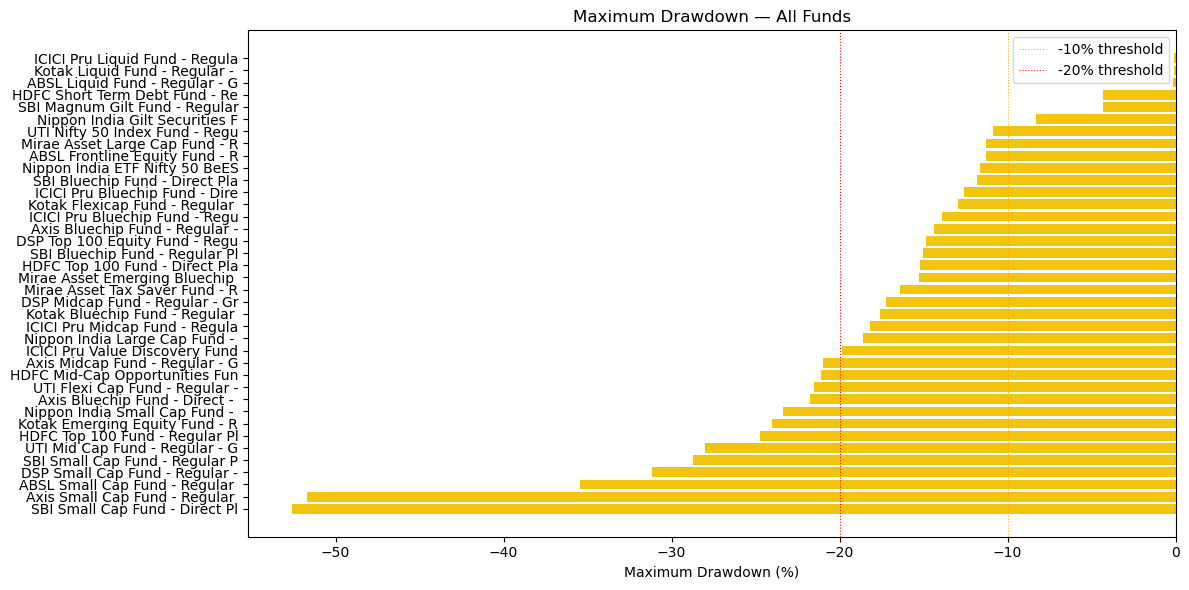

In [8]:
dd_rows = []
for code, grp in nav.groupby('amfi_code'):
    grp = grp.sort_values('date').copy()
    grp['running_max'] = grp['nav'].cummax()
    grp['drawdown']    = grp['nav'] / grp['running_max'] - 1
    min_idx            = grp['drawdown'].idxmin()
    max_dd             = grp.loc[min_idx, 'drawdown']
    trough_date        = grp.loc[min_idx, 'date']
    # Peak = last date before trough where NAV was at running max
    before_trough = grp[grp['date'] <= trough_date]
    peak_date = before_trough.loc[before_trough['nav'] == before_trough['nav'].max(), 'date'].iloc[-1]
    name = fund_master.loc[fund_master['amfi_code'] == code, 'scheme_name'].values
    dd_rows.append({
        'amfi_code'  : code,
        'scheme_name': name[0] if len(name) else str(code),
        'max_drawdown': max_dd,
        'peak_date'  : peak_date,
        'trough_date': trough_date,
        'dd_duration_days': (trough_date - peak_date).days
    })

dd_df = pd.DataFrame(dd_rows).sort_values('max_drawdown')  # most negative first
dd_df['dd_rank'] = dd_df['max_drawdown'].rank(ascending=False).astype(int)  # higher = less drawdown = better

print('Worst 10 Drawdowns:')
print(dd_df[['scheme_name','max_drawdown','peak_date','trough_date','dd_duration_days']]
      .head(10).to_string(index=False))

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(dd_df['scheme_name'].str[:30], dd_df['max_drawdown'] * 100,
               color=['#c0392b' if v < -20 else '#e67e22' if v < -10 else '#f1c40f'
                      for v in dd_df['max_drawdown']])
ax.set_xlabel('Maximum Drawdown (%)')
ax.set_title('Maximum Drawdown — All Funds')
ax.axvline(-10, color='orange', linestyle=':', linewidth=0.8, label='-10% threshold')
ax.axvline(-20, color='red',    linestyle=':', linewidth=0.8, label='-20% threshold')
ax.legend()
plt.tight_layout()
plt.savefig('../charts/max_drawdown.png', dpi=150, bbox_inches='tight')
plt.show()

### Insight 6

Small-cap funds experienced the largest drawdowns, with SBI Small Cap Fund (Direct Plan) recording the deepest decline of approximately -52.6%, followed by Axis Small Cap Fund (-51.7%). In contrast, liquid, gilt, and short-duration debt funds generally remained within a -5% to -10% drawdown range, demonstrating substantially lower downside risk.

## Task 7 — Fund Scorecard (0–100)
Weights: 3yr return 30% | Sharpe 25% | Alpha 20% | Expense ratio 15% (inverse) | Max DD 10% (inverse)

fund_scorecard.csv saved.
                                           scheme_name  score
1        Mirae Asset Large Cap Fund - Regular - Growth  88.12
2        Mirae Asset Tax Saver Fund - Regular - Growth  85.69
3               Kotak Flexicap Fund - Regular - Growth  83.12
4            SBI Bluechip Fund - Regular Plan - Growth  82.31
5        ABSL Frontline Equity Fund - Regular - Growth  80.19
6                   DSP Midcap Fund - Regular - Growth  79.88
7   HDFC Mid-Cap Opportunities Fund - Regular - Growth  78.12
8             ICICI Pru Midcap Fund - Regular - Growth  78.12
9                  Axis Midcap Fund - Regular - Growth  74.38
10           ICICI Pru Bluechip Fund - Direct - Growth  73.62


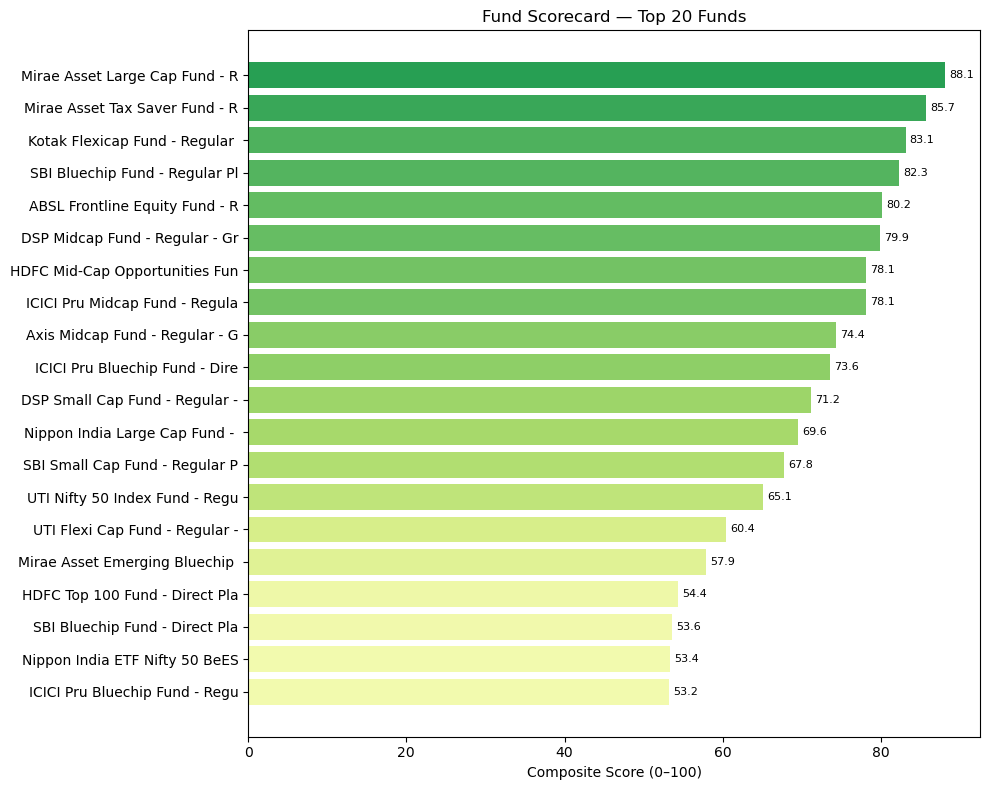

In [9]:
cagr_3yr = cagr_df[['amfi_code','cagr_3yr']].copy()
cagr_3yr['return_rank'] = cagr_3yr['cagr_3yr'].rank(ascending=True)  
expense = performance[['amfi_code','expense_ratio_pct']].copy()
expense['expense_rank'] = expense['expense_ratio_pct'].rank(ascending=False) 
scorecard = (cagr_3yr[['amfi_code','return_rank']]
             .merge(sharpe_df[['amfi_code','sharpe_rank']], on='amfi_code')
             .merge(ab_df[['amfi_code','alpha_rank']],      on='amfi_code')
             .merge(expense[['amfi_code','expense_rank']],  on='amfi_code')
             .merge(dd_df[['amfi_code','dd_rank']],         on='amfi_code'))

N = len(scorecard)
scorecard['score'] = (
    0.30 * (scorecard['return_rank']  / N * 100) +
    0.25 * (scorecard['sharpe_rank'].apply(lambda r: (N - r + 1)) / N * 100) +
    0.20 * (scorecard['alpha_rank'].apply(lambda r: (N - r + 1))  / N * 100) +
    0.15 * (scorecard['expense_rank'].apply(lambda r: (N - r + 1))/ N * 100) +
    0.10 * (scorecard['dd_rank'].apply(lambda r: (N - r + 1))     / N * 100)
).round(2)

scorecard = scorecard.merge(fund_master[['amfi_code','scheme_name']], on='amfi_code', how='left')
scorecard = scorecard.sort_values('score', ascending=False).reset_index(drop=True)
scorecard.index += 1


scorecard.to_csv('../charts/fund_scorecard.csv', index=True, index_label='rank')
print('fund_scorecard.csv saved.')
print(scorecard[['scheme_name','score']].head(10).to_string())


top20 = scorecard.head(20)
fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.barh(top20['scheme_name'].str[:30][::-1], top20['score'][::-1],
               color=plt.cm.RdYlGn(top20['score'][::-1] / 100))
ax.set_xlabel('Composite Score (0–100)')
ax.set_title('Fund Scorecard — Top 20 Funds')
for bar, score in zip(bars, top20['score'][::-1]):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{score:.1f}', va='center', fontsize=8)
plt.tight_layout()
plt.savefig('../charts/fund_scorecard.png', dpi=150, bbox_inches='tight')
plt.show()

### Insight 7

The composite scorecard identifies Mirae Asset Large Cap Fund (88.1), Mirae Asset Tax Saver Fund (85.7), and Kotak Flexicap Fund (83.1) as the highest-ranked schemes. These funds consistently combine strong medium-term returns, superior risk-adjusted performance, controlled drawdowns, and reasonable expense ratios, making them the most balanced performers across all evaluation criteria.

## Task 8 — Benchmark Comparison (Top 5 Funds vs Nifty 50 & Nifty 100)
Tracking Error = `std(fund_return − benchmark_return) × √252`

(1150, 3)
(1150, 3)


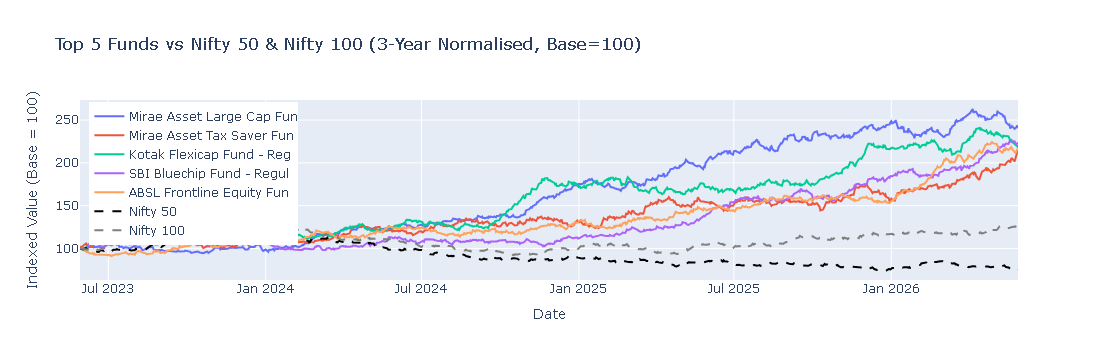


Tracking Error vs Nifty 100 (annualised):
                                  scheme_name  tracking_error
Mirae Asset Large Cap Fund - Regular - Growth        0.187867
Mirae Asset Tax Saver Fund - Regular - Growth        0.216924
       Kotak Flexicap Fund - Regular - Growth        0.206410
    SBI Bluechip Fund - Regular Plan - Growth        0.193475
ABSL Frontline Equity Fund - Regular - Growth        0.188852


In [23]:

top5_codes = scorecard.head(5)['amfi_code'].tolist()
top5_names = scorecard.head(5).set_index('amfi_code')['scheme_name'].to_dict()


end_date   = nav['date'].max()
start_date = end_date - pd.DateOffset(years=3)

nifty50  = benchmark[benchmark['index_name'] == 'NIFTY50'].copy()
nifty100_bm = benchmark[benchmark['index_name'] == 'NIFTY100'].copy()

def normalise(series):
    return series / series.iloc[0] * 100

fig = go.Figure()


tracking_errors = []
for code in top5_codes:
    fund_nav = nav[(nav['amfi_code'] == code) & (nav['date'] >= start_date)].sort_values('date')
    norm = normalise(fund_nav['nav'])
    fig.add_trace(go.Scatter(x=fund_nav['date'], y=norm,
                             name=top5_names[code][:25], mode='lines'))
    # Tracking error vs Nifty 100
    fund_ret = fund_nav[['date','daily_return']].dropna()
    bm_ret = nifty100[nifty100['date'] >= start_date][['date','bm_return']].dropna()
    merged_te = fund_ret.merge(bm_ret, on='date', how='inner').dropna()
    if len(merged_te) > 10:
        te = (merged_te['daily_return'] - merged_te['bm_return']).std() * np.sqrt(252)
        tracking_errors.append({'scheme_name': top5_names[code], 'tracking_error': te})


for bm, color, name in [(nifty50, 'black', 'Nifty 50'), (nifty100_bm, 'grey', 'Nifty 100')]:
    bm_3y = bm[bm['date'] >= start_date].sort_values('date')
    if len(bm_3y) > 0:
        norm_bm = normalise(bm_3y['close_value'])
        fig.add_trace(go.Scatter(x=bm_3y['date'], y=norm_bm, name=name,
                                 line=dict(color=color, dash='dash', width=2)))

fig.update_layout(
    title='Top 5 Funds vs Nifty 50 & Nifty 100 (3-Year Normalised, Base=100)',
    xaxis_title='Date', yaxis_title='Indexed Value (Base = 100)',
    legend=dict(x=0.01, y=0.99), hovermode='x unified'
)
fig.write_image('../charts/benchmark_comparison.png')
fig.show()


te_df = pd.DataFrame(tracking_errors)
print('\nTracking Error vs Nifty 100 (annualised):')
print(te_df.to_string(index=False))

### Insight 8

Among the top-ranked schemes, Mirae Asset Large Cap Fund delivered the strongest cumulative growth over the three-year period, followed by Kotak Flexicap Fund and SBI Bluechip Fund. The selected funds substantially increased their normalized values, demonstrating consistent long-term wealth creation across varying market conditions.